In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fitted Dose-Response

## GDSC1

In [2]:
gdsc1 = pd.read_excel("data/GDSC/GDSC1_fitted_dose_response_27Oct23.xlsx")

In [5]:
gdsc1.shape

(333161, 19)

In [3]:
gdsc1 = gdsc1[["CELL_LINE_NAME", "TCGA_DESC", "DRUG_NAME", "PATHWAY_NAME", "LN_IC50"]]

## GDSC2

In [4]:
gdsc2 = pd.read_excel("data/GDSC/GDSC2_fitted_dose_response_27Oct23.xlsx")

In [8]:
gdsc2.shape

(242036, 19)

In [5]:
gdsc2 = gdsc2[["CELL_LINE_NAME", "TCGA_DESC", "DRUG_NAME", "PUTATIVE_TARGET", "PATHWAY_NAME", "LN_IC50"]]


## Filtering and merging 

In [6]:
gdsc1 = gdsc1[~gdsc1.DRUG_NAME.isin(gdsc2.DRUG_NAME)]

In [7]:
dose_response = pd.concat([gdsc1, gdsc2], axis=0)

In [12]:
dose_response

,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,LN_IC50,PUTATIVE_TARGET
750,ES5,UNCLASSIFIED,Sunitinib,RTK signaling,3.773630,NaN
751,ES7,UNCLASSIFIED,Sunitinib,RTK signaling,2.990953,NaN
752,EW-11,UNCLASSIFIED,Sunitinib,RTK signaling,3.600300,NaN
753,SK-ES-1,UNCLASSIFIED,Sunitinib,RTK signaling,0.830185,NaN
754,COLO-829,SKCM,Sunitinib,RTK signaling,5.417977,NaN
...,...,...,...,...,...,...
242031,SNU-175,COREAD,N-acetyl cysteine,Metabolism,10.127082,Metabolism
242032,SNU-407,COREAD,N-acetyl cysteine,Metabolism,8.576377,Metabolism
242033,SNU-61,COREAD,N-acetyl cysteine,Metabolism,10.519636,Metabolism
242034,SNU-C5,COREAD,N-acetyl cysteine,Metabolism,10.694579,Metabolism


In [8]:
dose_response["TCGA_DESC"] = dose_response.TCGA_DESC.fillna("UNCLASSIFIED")

In [9]:
dose_response["TCGA_DESC"] = dose_response["TCGA_DESC"].replace("OTHER", "UNCLASSIFIED")

## Microarray Data

In [19]:
expression_data = pd.read_table("data/GDSC/Cell_line_RMA_proc_basalExp.txt.zip", sep="\t")

In [42]:
expression_data.head()

,DATA.906826,DATA.687983,DATA.910927,DATA.1240138,DATA.1240139,DATA.906792,DATA.910688,DATA.1240135,DATA.1290812,DATA.907045,...,DATA.753584,DATA.907044,DATA.998184,DATA.908145,DATA.1659787,DATA.1298157,DATA.1480372,DATA.1298533,DATA.930299,DATA.905954.1
GENE_SYMBOLS,,,,,,,,,,,,,,,,,,,,,
TSPAN6,7.632023,7.548671,8.712338,7.797142,7.729268,7.074533,3.285198,6.961606,5.943046,3.455951,...,7.105637,3.236503,3.038892,8.373223,6.932178,8.441628,8.422922,8.089255,3.112333,7.153127
TNMD,2.964585,2.777716,2.643508,2.817923,2.957739,2.889677,2.828203,2.874751,2.686874,3.290184,...,2.798847,2.745137,2.976406,2.852552,2.622630,2.639276,2.879890,2.521169,2.870468,2.834285
DPM1,10.379553,11.807341,9.880733,9.883471,10.418840,9.773987,10.264385,10.205931,10.299757,11.570155,...,10.486486,10.442951,10.311962,10.454830,10.418475,11.463742,10.557777,10.792750,9.873902,10.788218
SCYL3,3.614794,4.066887,3.956230,4.063701,4.341500,4.270903,5.968168,3.715033,3.848112,5.560883,...,3.696835,4.624013,4.348524,3.858121,3.947561,4.425849,3.550390,4.443337,4.266828,4.100493
C1orf112,3.380681,3.732485,3.236620,3.558414,3.840373,3.815055,3.011867,3.268449,3.352835,3.571228,...,3.726833,3.947744,3.806584,3.196988,3.814831,4.384732,4.247189,3.071359,3.230197,3.435795


In [20]:
expression_data.drop(columns="GENE_title", inplace=True)

In [21]:
expression_data.set_index("GENE_SYMBOLS", inplace=True)

In [41]:
expression_data.shape

(17737, 1018)

In [22]:
gn = pd.read_csv("data/gene_names.csv", header=None)
gn = pd.Series(gn[0].tolist())

In [23]:
expression_data = expression_data[expression_data.index.isin(gn)]

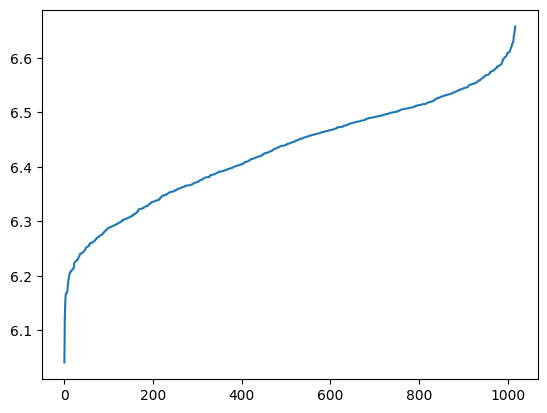

In [47]:
plt.plot(np.sort(expression_data.mean(0)))

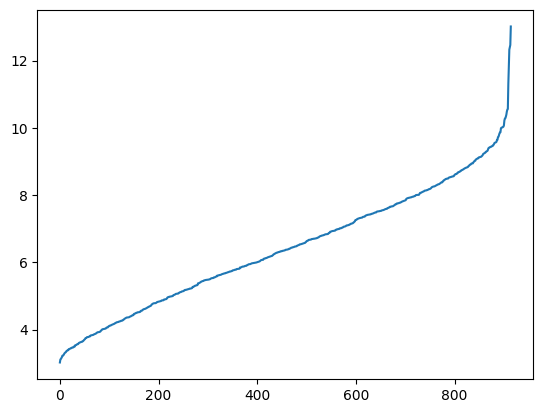

In [48]:
plt.plot(np.sort(expression_data.mean(1)))

In [24]:

expression_data = expression_data.transpose()

In [25]:
# mean and std gene-wise computation
expression_data = (expression_data-expression_data.mean(0))/expression_data.std(0)

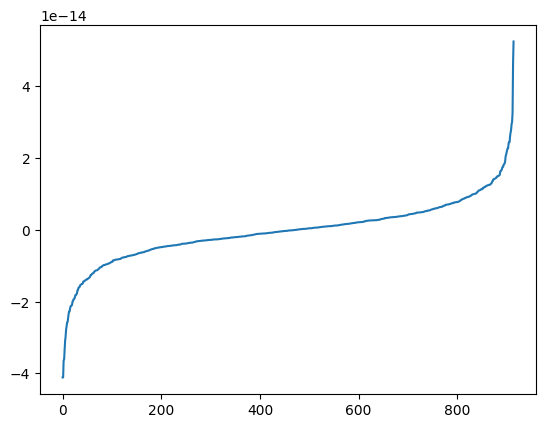

In [136]:
plt.plot(np.sort(expression_data.mean(0)))

In [26]:

expression_data = expression_data.reindex(columns=gn, fill_value=0.0)

In [27]:
expression_data.head()

,DDR1,PAX8,RPS5,ABCF1,SPAG7,RHOA,RNPS1,SMNDC1,ATP6V0B,RPS6,...,P4HTM,SLC27A3,TBXA2R,RTN2,TSTA3,PPARD,GNA11,WDTC1,PLSCR3,NPEPL1
DATA.906826,-0.305732,0.711282,1.509111,-0.744803,-0.048286,1.599555,0.119316,-0.595470,-0.220851,0.448362,...,1.034075,-1.161202,-0.210198,0.203552,-1.013130,-1.163634,1.210261,-1.711636,0.0,-0.167445
DATA.687983,-0.935571,-0.577132,0.753595,1.502862,-0.038186,0.642719,0.511261,2.002503,1.135262,-0.158210,...,-0.123986,1.011285,0.787891,0.240005,-0.250176,0.185568,0.310498,-0.482458,0.0,-0.843909
DATA.910927,0.755947,2.055566,0.247765,-0.369613,0.337902,0.814002,-0.525698,-0.445205,-0.168421,-0.072471,...,0.442055,-0.366715,-0.065420,-0.995984,0.527206,-0.583380,0.503162,-0.853046,0.0,0.280595
DATA.1240138,1.510521,-0.448138,-0.394027,0.703262,0.693010,-1.090523,-0.290837,0.441743,-1.015708,-0.353947,...,0.712327,0.987650,0.115148,-0.145012,0.532257,0.123279,0.808695,-0.963806,0.0,1.259087
DATA.1240139,-0.582805,-0.551286,0.427409,1.040927,1.093342,-0.200309,-0.199155,1.301375,0.030533,-0.397055,...,-0.295177,0.023364,-0.667009,-0.635744,-1.882567,-0.092166,0.093322,-0.305322,0.0,0.604565


In [139]:
expression_data.index

Index(['DATA.906826', 'DATA.687983', 'DATA.910927', 'DATA.1240138',
       'DATA.1240139', 'DATA.906792', 'DATA.910688', 'DATA.1240135',
       'DATA.1290812', 'DATA.907045',
       ...
       'DATA.753584', 'DATA.907044', 'DATA.998184', 'DATA.908145',
       'DATA.1659787', 'DATA.1298157', 'DATA.1480372', 'DATA.1298533',
       'DATA.930299', 'DATA.905954.1'],
      dtype='object', length=1018)

In [28]:
cell_ids = expression_data.index.str.split(".").str[1].astype(int)

In [29]:
cell_ids = cell_ids.to_series()

In [30]:
# filter dose-response df for those cell lines present in expression data
cell_with_exp_data = dose_response[dose_response.COSMIC_ID.isin(cell_ids)]

In [668]:
cell_with_exp_data.index.get_level_values(1).unique

Index(['Camptothecin', 'Vinblastine', 'Cisplatin', 'Cytarabine', 'Docetaxel',
       'Methotrexate', 'Tretinoin', 'Gefitinib', 'Navitoclax', 'Vorinostat',
       ...
       'BMS-754807', 'JQ1', 'PFI-1', 'IOX2', 'CHIR-99021', 'SGC0946',
       'GSK2830371', 'glutathione', 'alpha-lipoic acid', 'N-acetyl cysteine'],
      dtype='object', name='DRUG_NAME', length=228)

In [31]:
cell_line_name = cell_ids.map(cell_with_exp_data.set_index("COSMIC_ID")["CELL_LINE_NAME"].to_dict())

In [32]:
expression_data = expression_data.set_axis(cell_line_name, axis=0)

In [876]:
atomic_smiles = pd.read_csv("output/all_smiles_2048_bits.csv",
                          sep="\t")
atomic_smiles = atomic_smiles.transpose()

In [150]:
atomic_smiles.shape

(27839, 2048)

In [884]:
dose_response.DRUG_NAME.nunique()

286

In [878]:
len(atomic_smiles.index.intersection(dose_response.DRUG_NAME.unique()))

27

In [883]:
len(pd.Index(dose_response.DRUG_NAME.unique()).intersection(atomic_smiles.index))

27

# Bulk Data 

In [10]:
expression_data = pd.read_csv("data/GDSC/cell_model_passports/rnaseq_all_20250117.csv")

In [15]:
expression_data.head()

,model_name,model_id,gene_symbol,ensembl_gene_id,gene_id,htseq_read_count,rsem_expected_count,rsem_fpkm,rsem_tpm,htseq_fpkm,data_source
0,LC-1-sq-SF,SIDM01226,TSPAN6,ENSG00000000003,SIDG39683,NaN,2383.0,NaN,4.3320,NaN,Broad
1,COG-AR-359,SIDM01488,TSPAN6,ENSG00000000003,SIDG39683,NaN,2529.0,NaN,4.5674,NaN,Broad
2,COLO-794,SIDM00514,TSPAN6,ENSG00000000003,SIDG39683,NaN,1552.0,NaN,3.1506,NaN,Broad
3,KKU-M213,SIDM01801,TSPAN6,ENSG00000000003,SIDG39683,NaN,5657.0,NaN,5.0853,NaN,Broad
4,RT4,SIDM01085,TSPAN6,ENSG00000000003,SIDG39683,NaN,22806.0,NaN,6.7294,NaN,Broad


In [11]:
expression_data = expression_data.pivot_table(columns="model_name",
                                              index="gene_symbol",
                                              values="rsem_expected_count",
                                              dropna=False,
                                              fill_value=0.0
                                              )

In [12]:
expression_data = expression_data.loc[
    :,
    expression_data.columns.intersection(dose_response.CELL_LINE_NAME)]

In [13]:
expression_data.columns.nunique()

952

In [14]:
expression_data.head()

model_name,22RV1,23132-87,42-MG-BA,451Lu,5637,639-V,647-V,697,769-P,786-0,...,WSU-DLCL2,WSU-NHL,YAPC,YH-13,YKG-1,YT,ZR-75-30,huH-1,no-10,no-11
gene_symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,69.93,1.00,627.34,1503.37,3.00,496.02,22.00,826.22,2.0,0.00,...,775.78,976.140,10.48,483.98,286.67,23.28,715.030,26.47,321.085,193.02
A1BG-AS1,546.13,9.75,1023.90,1767.51,4.18,558.29,52.48,828.28,0.0,0.43,...,399.47,1399.335,15.68,727.96,399.06,51.74,846.935,9.49,394.750,209.40
A1CF,3185.00,851.00,5.00,2.00,1.00,2.00,0.00,0.00,174.8,4.00,...,0.00,20.000,7.00,3.00,1.00,4.00,0.500,9848.50,5.520,2.00
A2M,645.00,1.00,10.00,90938.24,11.00,2.00,14.00,41.00,30.0,2.00,...,11.00,17.685,7.50,99.50,67.00,10.00,113.670,53.00,14.500,327.00
A2M-AS1,179.00,30.00,0.00,72.76,5.00,14.00,24.00,2.00,46.0,0.00,...,11.00,13.815,25.00,9.00,1.00,9.00,47.830,25.00,0.000,0.00


In [15]:
# filter dose-response df for those cell lines present in expression data
dose_response = dose_response[dose_response.CELL_LINE_NAME.isin(expression_data.columns)]

In [16]:
dose_response.CELL_LINE_NAME.nunique()

952

In [17]:
dose_response.DRUG_NAME.nunique()

542

In [ ]:
##################################################
# DATA NORMALIZATION
##################################################

In [18]:
expression_data_copy = expression_data

In [ ]:
# expression_data = expression_data_copy

In [ ]:
plt.plot(np.sort(expression_data.std(0)))

In [19]:
#expression_data = expression_data.fillna(0) 
expression_data = expression_data.loc[expression_data.var(1)>0,]
expression_data = ((expression_data/expression_data.sum(0))*1e6).transpose()
expression_data = np.log1p(expression_data)/np.log(2)

In [20]:
expression_data.isna().any().value_counts()

False    37958
Name: count, dtype: int64

In [21]:
expression_data.shape

(952, 37958)

In [22]:
expression_data_copy = expression_data

In [ ]:
############################################################
#
#   FILTERING GENES TO L1000
#
############################################################

In [85]:
gn = pd.read_csv("output/regression/L1000_gene_names.csv", header=None)
gn = pd.Series(gn[0].tolist())

In [89]:
gn

0        DDR1
1        PAX8
2        RPS5
3       ABCF1
4       SPAG7
        ...  
973     PPARD
974     GNA11
975     WDTC1
976    PLSCR3
977    NPEPL1
Length: 978, dtype: object

In [95]:

expression_data = expression_data.loc[:, expression_data.columns.intersection(gn)]

In [98]:
expression_data.shape

(952, 946)

In [ ]:
#######################################
# SAVING L1000 GEX DATA
#######################################

# expression_data.to_csv("output/regression/L1000_GEX_data_filtered_logCPM.csv")

In [ ]:
############################################################
#
#   FILTERING GENES TO MSIGDB
#
############################################################

In [ ]:
import pickle5 as pickle

In [ ]:
with open("benchmarking/screendl/screendl/data/genelists/HallmarkPathways4384Genes.pkl", "rb") as f:
    hallmark_genes = pickle.load(f)

In [ ]:
expression_data = expression_data_copy

In [ ]:
expression_data = expression_data.loc[:, expression_data.columns.intersection(hallmark_genes)]

In [ ]:
expression_data.shape

(952, 4377)

In [ ]:
############################################################
#   SAVING GEX FOR MSIGDB
############################################################

# expression_data.to_csv("output/regression/msigdb_GEX_data_filtered_logCPM.csv")

In [ ]:
############################################################
#
#   FILTERING GENES TO PACCMANN
#
############################################################

In [42]:
paccmann_genes = pd.read_csv(
    "benchmarking/paccmann_gene_list.txt",
    header=None
)

In [51]:
expression_data = expression_data.loc[:,expression_data.columns.intersection(paccmann_genes[0])]

In [52]:
##########################################################
#   SAVING PACCMANN GEX DATA
##########################################################
expression_data.to_csv("output/regression/paccmann_GEX_data_filtered_logCPM.csv")


In [76]:
expression_data.shape

(952, 2083)

# Drug Data

In [53]:
drugs_GDSC = dose_response.DRUG_NAME.unique()

In [54]:
pd.Series(drugs_GDSC).value_counts()

Sunitinib              1
Bicalutamide           1
SCH772984              1
EPZ5676                1
Taselisib              1
                      ..
AICA Ribonucleotide    1
RU-SKI 43              1
Kobe2602               1
BAM7                   1
N-acetyl cysteine      1
Name: count, Length: 542, dtype: int64

## PubChem Query 

In [57]:
import pubchempy as pcp

In [58]:
def get_smiles(compound_name):
    compound = pcp.get_compounds(compound_name, "name")
    if compound:
        return compound[0].canonical_smiles
    return None

In [59]:
drugs_GDSC_smiles = list(map(get_smiles, drugs_GDSC.tolist()))

/tmp/ipykernel_12177/1045816845.py:4: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  return compound[0].canonical_smiles


In [61]:
drugs_GDSC_smiles_copy = drugs_GDSC_smiles

In [60]:
len(drugs_GDSC_smiles)

542

In [62]:
drugs_GDSC_smiles = dict(zip(drugs_GDSC.tolist(), drugs_GDSC_smiles))

In [ ]:
drugs_GDSC_smiles

In [47]:
drugs_missing = {k: v for k, v in drugs_GDSC_smiles.items() if v is None}

In [67]:
missing = {'Venotoclax':'CC1(C)CCC(CN2CCN(CC2)C2=CC=C(C(=O)NS(=O)(=O)C3=CC=C(NCC4CCOCC4)C(=C3)[N+]([O-])=O)C(OC3=CN=C4NC=CC4=C3)=C2)=C(C1)C1=CC=C(Cl)C=C1',
 'Bleomycin (10 uM)' : '[H][C@](C)(NC(=O)[C@@]([H])(NC(=O)C1=NC(=NC(N)=C1C)[C@H](CC(N)=O)NC[C@H](N)C(N)=O)[C@@]([H])(OC1OC(CO)C(O)C(O)C1OC1OC(CO)C(O)C(OC(N)=O)C1O)C1=CNC=N1)[C@@H](O)[C@H](C)C(=O)N[C@]([H])(C(=O)NCCC1=NC(=CS1)C1=NC(=CS1)C(=O)NCCC[S+](C)C)[C@@]([H])(C)O',
 'Nutlin-3a (-)':'CC(C)OC1=C(C=CC(=C1)OC)C2=N[C@H]([C@H](N2C(=O)N3CCNC(=O)C3)C4=CC=C(C=C4)Cl)C5=CC=C(C=C5)Cl'
}

In [65]:
drugs_GDSC_smiles = {k: v for k, v in drugs_GDSC_smiles.items() if v is not None}

In [66]:
len(drugs_GDSC_smiles)

410

In [68]:
drugs_GDSC_smiles.update(missing)

In [ ]:
############################################################
#
#   SAVING SMILES DATA VECTORIZED
#
############################################################


(pd.Series(drugs_GDSC_smiles, name="smiles")
 .rename_axis("drug_name")
 .reset_index()
 .to_csv("output/regression/drug_smiles.tsv", sep="\t", index=False)
)

## SMILES Vectorization 

In [53]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

In [54]:
def get_molecule_radius(smiles):
    """Determine a suitable radius based on the size of the molecule."""
    molecule = Chem.MolFromSmiles(smiles)
    num_atoms = molecule.GetNumAtoms()
    
    # Example heuristic: adjust radius based on the number of atoms
    if num_atoms <= 10:
        return 1  # Small molecule
    elif num_atoms <= 30:
        return 2  # Medium molecule
    else:
        return 3  # Large molecule

def smiles_to_morgan_atomic(smiles):
    """Generate a Morgan fingerprint with an appropriate radius."""
    radius = get_molecule_radius(smiles)
    molecule = Chem.MolFromSmiles(smiles)
    fpgen = AllChem.GetMorganGenerator(radius, fpSize=512)
    fingerprint = fpgen.GetFingerprintAsNumPy(molecule)
    
    return fingerprint

In [55]:
# Get atomic SMILES
vector_smiles = list(map(smiles_to_morgan_atomic, list(drugs_GDSC_smiles.values())))

In [ ]:
vector_smiles

In [56]:
vector_smiles = dict(zip(list(drugs_GDSC_smiles.keys()), vector_smiles))

In [57]:
vector_smiles = pd.DataFrame(vector_smiles).transpose()

In [58]:
vector_smiles

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
Sunitinib,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
PHA-665752,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Cyclopamine,0,0,0,0,0,0,0,1,0,0,...,1,0,1,0,0,1,1,0,0,0
AZ628,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
Imatinib,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alpha-lipoic acid,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
N-acetyl cysteine,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Venotoclax,0,0,0,0,0,0,0,1,0,0,...,1,1,0,0,0,1,0,0,0,1
Bleomycin (10 uM),0,1,0,0,0,0,1,0,1,0,...,0,0,0,0,1,1,0,0,0,0


In [ ]:
############################################################
#
#   SAVING SMILES DATA VECTORIZED
#
############################################################

# vector_smiles.to_csv("output/regression/vector_smiles_512.csv", header=True, index=True)

In [34]:
dose_response.shape

(343704, 6)

In [33]:
# filter by succesfully retrieved SMILES
dose_response = dose_response[dose_response.DRUG_NAME.isin(pd.Series(vector_smiles.index))]

In [ ]:
############################################################
#
#   SAVING DOSE-RESPONSE DATA
#
############################################################


# dose_response.to_csv("output/regression/dose_response_matrix.csv", header=True, index=True)

# DR data visualization

In [2]:
dose_response = pd.read_csv("output/regression/dose_response_matrix.csv", index_col=0, header=0)

/tmp/ipykernel_8282/4006438872.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dose_response = pd.read_csv("output/regression/dose_response_matrix.csv", index_col=0, header=0)


dose_response_copy = dose_response

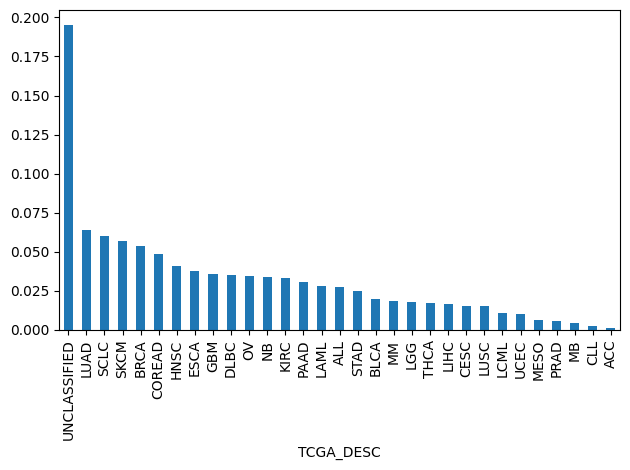

In [5]:
dose_response.TCGA_DESC.value_counts(normalize=True).plot.bar()
plt.tight_layout() 
#plt.savefig("slides/figures_regression/tcga_desc_distribution.png", dpi=600)

In [5]:
dose_response.head()

,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,LN_IC50,PUTATIVE_TARGET,Y_TRUE
750,ES5,UNCLASSIFIED,Sunitinib,RTK signaling,3.773630,NaN,0.466473
751,ES7,UNCLASSIFIED,Sunitinib,RTK signaling,2.990953,NaN,0.181225
752,EW-11,UNCLASSIFIED,Sunitinib,RTK signaling,3.600300,NaN,0.403303
753,SK-ES-1,UNCLASSIFIED,Sunitinib,RTK signaling,0.830185,NaN,-0.606271
754,COLO-829,SKCM,Sunitinib,RTK signaling,5.417977,NaN,1.065758


In [5]:
dose_response.PATHWAY_NAME.nunique()

24

dose_response = dose_response.loc[dose_response.TCGA_DESC=="HNSC"]

In [6]:
dose_response["Y_TRUE"] = (dose_response.LN_IC50-dose_response.LN_IC50.mean())/dose_response.LN_IC50.std()

/tmp/ipykernel_8282/1392051346.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dose_response["Y_TRUE"] = (dose_response.LN_IC50-dose_response.LN_IC50.mean())/dose_response.LN_IC50.std()


In [7]:
mat_dr = (dose_response
          .pivot_table(
              columns="TCGA_DESC",
              index="PATHWAY_NAME",
              values="Y_TRUE",
              aggfunc="mean",
              fill_value=0.0
              )
)

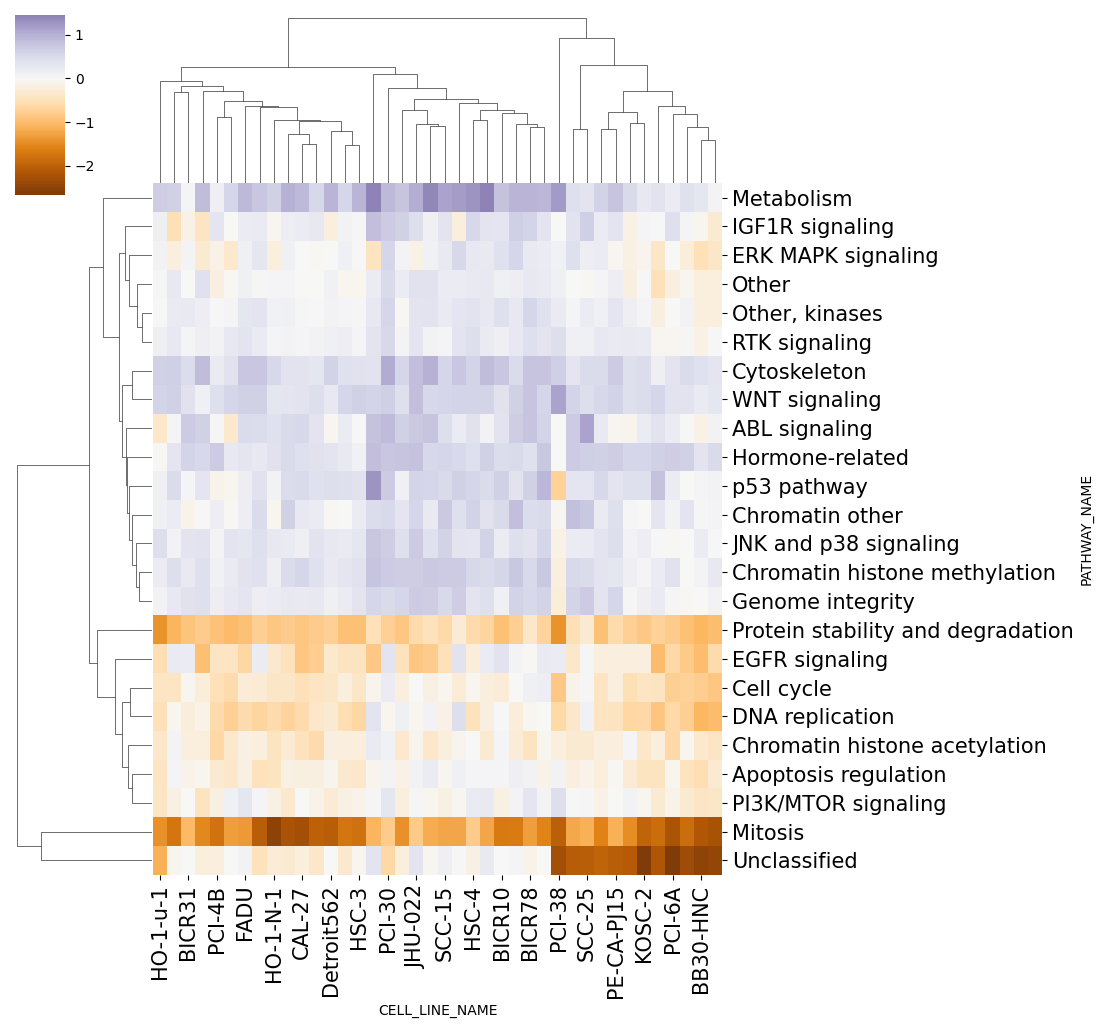

In [8]:
g = sns.clustermap(mat_dr,
                   row_cluster=True,
                   col_cluster=True,
                   cmap="PuOr", #seismic
                   standard_scale=None,
                   z_score=None,
                   center=0,
                   method="average",
                   metric="euclidean",
                   #cbar_kws={"orientation": "horizontal"},
                   #cbar_pos=(0.25, 0.89, 0.4, 0.02)
                   #col_colors=drug_class_colors
              )

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=15)
# g.savefig("slides/figures_regression/drug_response/DR_heatmap_tcga_pathway.pdf", dpi=600)
g

In [9]:
import umap

In [10]:
import plotly.express as px

In [11]:
reducer = umap.UMAP(
    init="pca",
    random_state=14,
    n_components=2,
)

In [23]:
del reducer

In [22]:
mat_dr = (dose_response
          .pivot_table(
              columns="CELL_LINE_NAME",
              index="DRUG_NAME",
              values="Y_TRUE",
              aggfunc="mean",
              fill_value=0.0
              )
)

In [13]:

z_umap = reducer.fit_transform(mat_dr)


/media/christian97/Data/PhD/drug_repurposing/venv_drug_repurposing/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [14]:
drug_mean = mat_dr.mean(1)

In [16]:
(
    drug_mean.abs() * 10
).describe()

count    40.000000
mean      1.164502
std       0.761079
min       0.042840
25%       0.585101
50%       1.011983
75%       1.657736
max       3.128951
dtype: float64

In [20]:
drug_mean.describe()

count    40.000000
mean      0.006488
std       0.140206
min      -0.312895
25%      -0.089739
50%       0.003662
75%       0.116914
max       0.271903
dtype: float64

In [21]:
fig = px.scatter(z_umap,
                 x=0,
                 y=1,
                 color=drug_mean, # response_color_cline
                 size=drug_mean.abs()*10,
                 size_max=20,
                 height=500,
                 width=500,
                 # color_discrete_map=color_map_sensitivity,
                 color_continuous_scale="PuOr",
                 range_color=(-0.3,0.3), #-2,2
                 # category_orders={"color": category_order},
                 # hover_data=[cline_pathways] ,
                 template="simple_white",
                #  title= "Embedding with blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color" : "Response"
                       },
               )

fig.update_traces(
    marker=dict(
        # size=8,
        line=dict(width=1, color="DarkSlateGrey")
    )
)

fig.update_layout(font=dict(size=16, family="Helvetica"))
fig.update_yaxes(scaleanchor="x")

# fig.update_layout(
#     showlegend=True,
#     legend=dict(
#         orientation="h",           # horizontal layout
#         yanchor="top",
#         y=1.2,                    # move it below the plot
#         xanchor="center",
#         x=0.5                      # center it horizontally
#     )
# )

fig.update_layout(
    coloraxis_colorbar=dict(
        orientation="h",
        x=0.02,
        y=1.05,
        xanchor="left",
        yanchor="bottom",
        len=1,
        thickness=15
    )
)

In [37]:
# fig.write_image("slides/figures_regression/drug_response/DR_UMAP.pdf")

# ScreenDL signature vs L1000 signature

In [101]:
import pickle5 as pickle

In [102]:
with open("benchmarking/screendl/screendl/data/genelists/HallmarkPathways4384Genes.pkl", "rb") as f:
    hallmark_genes = pickle.load(f)

In [ ]:
set(hallmark_genes)

In [ ]:
gn = pd.read_csv("output/regression/L1000_gene_names.csv", header=None)
gn = pd.Series(gn[0].tolist())

In [ ]:
set(gn)

In [8]:
from matplotlib_venn import venn2

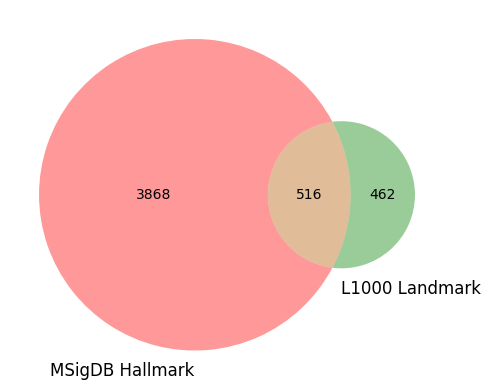

In [22]:
venn2([set(hallmark_genes), set(gn)], set_labels=("MSigDB Hallmark", "L1000 Landmark"))
plt.savefig("slides/venn_plot.png", dpi=600)

In [ ]:
# pd.Series(expression_data.columns.to_list()).to_csv("output/regression/hallmark_genes_in_data.csv", index=False)

# Cross Validation

In [16]:
vector_smiles = pd.read_csv("output/regression/vector_smiles_512.csv", index_col=0)

In [ ]:
vector_smiles.shape

In [ ]:
#################
#
# DWM model only
#
#################
expression_data = pd.read_csv("output/regression/L1000_GEX_data_filtered_logCPM.csv", index_col=0)

In [13]:
expression_data.shape

(952, 946)

In [ ]:
dose_response.head()

In [149]:
mean_tmp = dose_response.groupby("DRUG_NAME")["LN_IC50"].mean().to_dict()

In [150]:
std_tmp = dose_response.groupby("DRUG_NAME")["LN_IC50"].mean().to_dict()

In [ ]:
mean_tmp

In [ ]:
(dose_response["LN_IC50"] - dose_response["DRUG_NAME"].map(mean_tmp))/dose_response["DRUG_NAME"].map(std_tmp)

## Data splitting

In [9]:
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split

In [10]:
cell_lines = dose_response.CELL_LINE_NAME.unique()

In [11]:
len(cell_lines)

836

In [12]:
drugs = dose_response.DRUG_NAME.unique()

In [13]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

In [14]:
train_ratio = 0.8

In [ ]:
###############################################################################################################
#
#      Pancancer | NBS cells
#
###############################################################################################################


for n, (fit_idx, ev_idx) in enumerate(kf.split(cell_lines)):
    Path(f"output/regression/cross_validation/pancancer/NBS_cells/fold_{n}/").mkdir(parents=True, exist_ok=True)
        
    # Split set - To get train-val sets
    split_set = dose_response[dose_response.CELL_LINE_NAME.isin(list(cell_lines[fit_idx]))]
    
    # Test set - Model evaluation
    test_set = dose_response[dose_response.CELL_LINE_NAME.isin(list(cell_lines[ev_idx]))]
    
    # Train - val index
    train_set, val_set = train_test_split(split_set,
                                     train_size=train_ratio,
                                     stratify=split_set.TCGA_DESC,
                                     random_state=14)
    
    train_set.to_csv(f"output/regression/cross_validation/pancancer/NBS_cells/fold_{n}/train_set.csv")
    val_set.to_csv(f"output/regression/cross_validation/pancancer/NBS_cells/fold_{n}/val_set.csv")
    test_set.to_csv(f"output/regression/cross_validation/pancancer/NBS_cells/fold_{n}/test_set.csv")
    

In [15]:
###############################################################################################################
#
#      Solid tumors | NBS cells
#
###############################################################################################################


# for n, (fit_idx, ev_idx) in enumerate(kf.split(cell_lines)):
#     (Path(f"output/regression/cross_validation/solid_tumors/NBS_cells/fold_{n}/").
#      mkdir(parents=True, exist_ok=True)
#     )
        
#     # Split set - To get train-val sets
#     split_set = dose_response[dose_response.CELL_LINE_NAME.isin(list(cell_lines[fit_idx]))]
    
#     # Test set - Model evaluation
#     test_set = dose_response[dose_response.CELL_LINE_NAME.isin(list(cell_lines[ev_idx]))]
    
#     # Train - val index
#     train_set, val_set = train_test_split(split_set,
#                                      train_size=train_ratio,
#                                      stratify=split_set.TCGA_DESC,
#                                      random_state=14)
    
#     train_set.to_csv(f"output/regression/cross_validation/solid_tumors/NBS_cells/fold_{n}/train_set.csv")
#     val_set.to_csv(f"output/regression/cross_validation/solid_tumors/NBS_cells/fold_{n}/val_set.csv")
#     test_set.to_csv(f"output/regression/cross_validation/solid_tumors/NBS_cells/fold_{n}/test_set.csv")
    

In [ ]:
###############################################################################################################
#
#      Pancancer | NBS Drugs
#
###############################################################################################################



# for n, (fit_idx, ev_idx) in enumerate(kf.split(drugs)):
    
#     Path(f"output/regression/cross_validation/pancancer/NBS_drugs/fold_{n}/").mkdir(parents=True, exist_ok=True)
        
#     # Split set - To get train-val sets
#     split_set = dose_response[dose_response.DRUG_NAME.isin(list(drugs[fit_idx]))]
    
#     # Test set - Model evaluation
#     test_set = dose_response[dose_response.DRUG_NAME.isin(list(drugs[ev_idx]))]
    
#     # Train - val index
#     train_set, val_set = train_test_split(split_set,
#                                      train_size=train_ratio,
#                                      stratify=split_set.TCGA_DESC,
#                                      random_state=14)
    
#     train_set.to_csv(f"output/regression/cross_validation/pancancer/NBS_drugs/fold_{n}/train_set.csv")
#     val_set.to_csv(f"output/regression/cross_validation/pancancer/NBS_drugs/fold_{n}/val_set.csv")
#     test_set.to_csv(f"output/regression/cross_validation/pancancer/NBS_drugs/fold_{n}/test_set.csv")
    
    